In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer

from SCIKIT.Lesson6Simpleimputer import categorical_pipeline, preprocessor
from python1 import X_train


In [2]:
data=pd.read_csv("battery.csv")
df=pd.DataFrame(data)
df

,Battery Age,Daily Usage Hours,Gaming User,Design Capacity,Cycle Count,CPU Usage,GPU Usage,Power Consumption,Average Temperature,Full Charge Capacity,Battery Health
0,5,9.797617,0,57884,1267,64.587764,43.887115,84.366245,35.645636,44961.935220,76.923383
1,9,7.101557,0,63824,1500,45.542182,36.534144,80.629042,31.782432,46619.665590,73.496153
2,9,10.085255,0,79414,1500,64.640516,52.238349,87.853504,32.122879,63343.419989,81.514041
3,5,7.946047,0,61142,1153,55.095724,30.535647,69.686012,30.371133,50407.438833,79.742100
4,7,9.628460,0,50956,1500,60.145756,36.749489,64.734123,27.536232,34757.377982,67.882552
...,...,...,...,...,...,...,...,...,...,...,...
1195,3,8.145116,0,45427,862,49.925547,36.825892,60.941182,29.962729,38004.357612,88.323901
1196,1,10.547996,0,76416,175,67.256126,41.067671,88.640540,31.511997,75542.888586,98.458822
1197,3,10.110045,0,45731,769,71.571854,43.582965,93.196856,30.948869,39527.102725,85.268217
1198,0,7.886602,0,45799,0,50.066835,36.860473,78.345694,31.045672,45799.000000,99.891670


In [4]:
df.describe()


,Battery Age,Daily Usage Hours,Gaming User,Design Capacity,Cycle Count,CPU Usage,GPU Usage,Power Consumption,Average Temperature,Full Charge Capacity,Battery Health
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,4.571667,6.435078,0.102500,62049.919167,993.813333,50.047021,37.081954,68.510005,30.483731,51798.125944,82.944518
std,2.831939,3.149664,0.303431,10096.807179,527.254899,18.859965,17.485642,21.213489,2.624044,11598.140456,9.924455
min,0.000000,1.002497,0.000000,45002.000000,0.000000,9.151884,5.000000,20.133013,22.908857,28181.020459,59.840266
25%,2.000000,3.722104,0.000000,53583.250000,530.500000,34.223028,24.084790,52.238214,28.758142,42865.372454,75.315849
50%,5.000000,6.322145,0.000000,61888.000000,1188.000000,50.097711,34.979134,67.399336,30.398357,51698.379658,81.461246
75%,7.000000,9.162563,0.000000,70734.750000,1500.000000,64.294947,46.615097,82.529511,32.231464,60403.354634,91.414773
max,9.000000,11.986722,1.000000,79959.000000,1500.000000,100.000000,98.339932,137.154936,39.934239,79263.000000,100.000000


In [5]:
df.isnull().sum()


Battery Age             0
Daily Usage Hours       0
Gaming User             0
Design Capacity         0
Cycle Count             0
CPU Usage               0
GPU Usage               0
Power Consumption       0
Average Temperature     0
Full Charge Capacity    0
Battery Health          0
dtype: int64

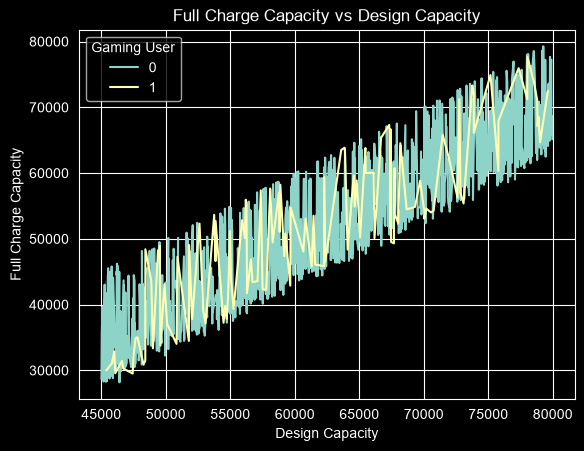

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(
    data=df,
    x="Design Capacity",
    y="Full Charge Capacity",
    hue="Gaming User"
)

plt.xlabel("Design Capacity")
plt.ylabel("Full Charge Capacity")
plt.title("Full Charge Capacity vs Design Capacity")
plt.show()

<Axes: xlabel='Battery Health', ylabel='Cycle Count'>

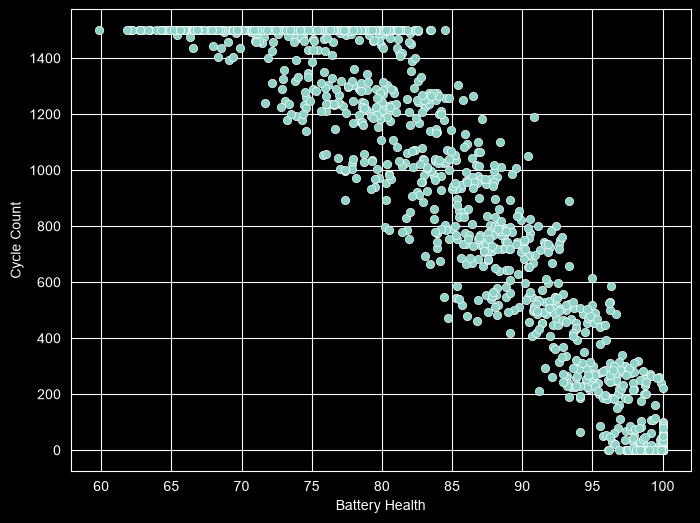

In [16]:
fig = plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    y="Cycle Count",
    x="Battery Health",
)

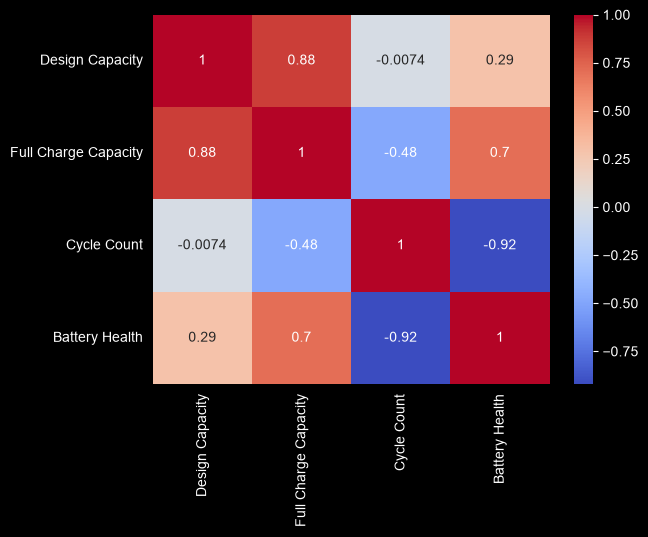

In [18]:
corr = df[[
    "Design Capacity",
    "Full Charge Capacity",
    "Cycle Count",
    "Battery Health"
]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [19]:
X=df.drop("Battery Health",axis=1)
Y=df["Battery Health"]

In [20]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [21]:
numerical_features = [
    "Battery Age",
    "Daily Usage Hours",
    "Design Capacity",
    "Cycle Count",
    "CPU Usage",
    "GPU Usage",
    "Power Consumption",
    "Average Temperature",
    "Full Charge Capacity"
]

categorical_features = [
    "Gaming User"
]

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder



numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [37]:
from sklearn.compose import ColumnTransformer
preprocessing=ColumnTransformer(
    [("numerical",numeric_pipeline,numerical_features),
     ("categorical",categorical_pipeline,categorical_features)


    ]
)
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

In [38]:
from sklearn.linear_model import Ridge

model=Pipeline([
    ("preprocessing",preprocessing),(
        "Model",Ridge(alpha=0.01),
    )
])

In [39]:
model.fit(
    X_train,
    Y_train
)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [41]:
prediction=model.predict(X_test)
print(prediction)

[ 79.98678246  89.20604464  70.7570395   90.67107927  69.89983215
 102.3179117   81.75741552  95.51339126  85.84936102  73.45506952
  82.47535199  97.06354266  88.30851033  66.817325    71.01810337
  82.02466169  70.53569041  88.69301528  91.62532105  79.0762194
  78.39408934  98.8569549   88.47761936  72.70582031  96.1946959
  93.76175521  75.25801598  73.7616351   77.50821612  77.39704269
  74.86965581  71.28625338  83.71720945  88.31152798  90.74908957
 102.1340344   91.04797928  94.72728819  84.43329726  89.77264328
  81.3416377   91.77172593  73.35048665 100.39911628  73.88441442
  75.68446381  98.94152779  91.75102066  76.90871423  93.50729897
  94.10376047  94.31730049  81.09872848  75.97058124  91.92066815
  86.28798397  88.56960162  80.50193866  95.25913052  68.21100465
  75.56754364  81.9664608   86.219536    73.10014921  69.63289292
 104.73810159  70.53766898  77.23072253  78.72988059  77.18255143
  90.3128214   90.96440508  85.79911144  76.02628323  96.92392362
  94.3253192

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(Y_test, predictions))
print("MSE:", mean_squared_error(Y_test, predictions))
print("R²:", r2_score(Y_test, predictions))

MAE: 1.788263685748404
MSE: 5.122703819273352
R²: 0.9458621202143958


In [43]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train,
    Y_train,
    cv=5,
    scoring="r2"
)

print("CV Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())
print("Std CV R²:", cv_scores.std())

CV Scores: [0.95430839 0.94976923 0.95714652 0.94477581 0.94735267]
Mean CV R²: 0.9506705242119267
Std CV R²: 0.004510891219843922


Battery Age             0
Daily Usage Hours       0
Gaming User             0
Design Capacity         0
Cycle Count             0
CPU Usage               0
GPU Usage               0
Power Consumption       0
Average Temperature     0
Full Charge Capacity    0
Battery Health          0
dtype: int64


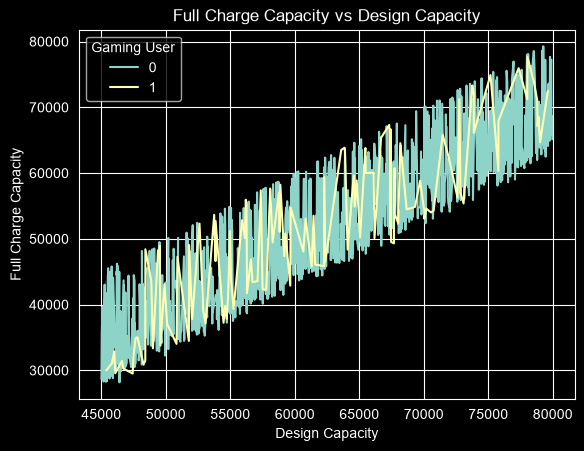

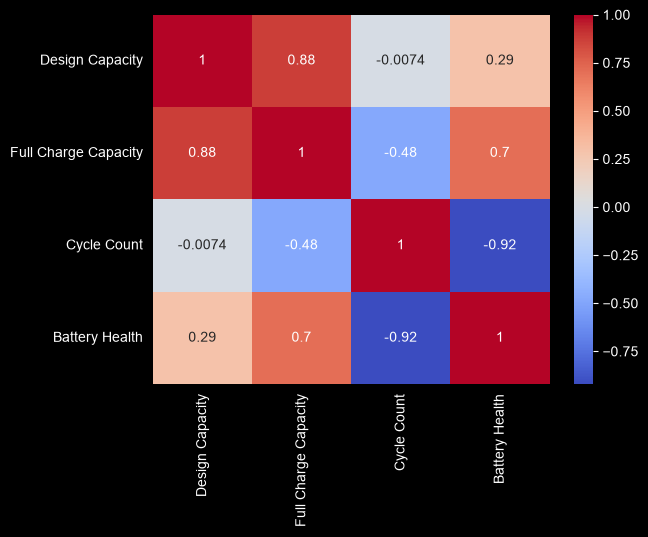

MAE: 1.788155293608007
MSE: 5.123164307270961
R²: 0.9458572536742371
CV Scores: [0.95430365 0.94970369 0.95712695 0.94482609 0.9473286 ]
Mean CV R²: 0.9506577970978916
Std CV R²: 0.004497662592415129


In [49]:
"""
Battery Health Predictor — Desktop GUI (Tkinter)
==================================================
Trains your Ridge Regression pipeline on battery.csv, then opens a
real desktop window with sliders to predict Battery Health.

Run with:
    pip install pandas numpy scikit-learn matplotlib
    python battery_health_gui.py

Requires battery.csv in the same folder (or edit CSV_PATH below).
"""

import tkinter as tk
from tkinter import ttk, messagebox

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

CSV_PATH = "battery.csv"

NUMERICAL_FEATURES = [
    "Battery Age", "Daily Usage Hours", "Design Capacity", "Cycle Count",
    "CPU Usage", "GPU Usage", "Power Consumption", "Average Temperature",
    "Full Charge Capacity",
]
CATEGORICAL_FEATURES = ["Gaming User"]


# ============================================================
# TRAIN THE MODEL
# ============================================================

def train_model():
    df = pd.read_csv(CSV_PATH)
    X = df.drop("Battery Health", axis=1)
    Y = df["Battery Health"]

    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])
    preprocessing = ColumnTransformer([
        ("numerical", numeric_pipeline, NUMERICAL_FEATURES),
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
    ])

    model = Pipeline([
        ("preprocessing", preprocessing),
        ("Model", Ridge(alpha=0.01)),
    ])
    model.fit(X_train, Y_train)

    preds = model.predict(X_test)
    metrics = {
        "MAE": mean_absolute_error(Y_test, preds),
        "MSE": mean_squared_error(Y_test, preds),
        "R2": r2_score(Y_test, preds),
    }
    return model, df, metrics


# ============================================================
# GUI
# ============================================================

BG = "#F4F6F8"
CARD = "#FFFFFF"
BORDER = "#E2E8F0"
TEXT = "#1F2937"
MUTED = "#6B7280"
BLUE = "#2563EB"
GREEN = "#16A34A"
ORANGE = "#D97706"
RED = "#DC2626"


class BatteryApp(tk.Tk):
    def __init__(self, model, df, metrics):
        super().__init__()
        self.model = model
        self.df = df
        self.metrics = metrics

        self.title("Battery Health Predictor")
        self.geometry("1000x680")
        self.minsize(880, 600)
        self.configure(bg=BG)

        self._build_style()
        self._build_layout()

    def _build_style(self):
        style = ttk.Style(self)
        style.theme_use("clam")
        style.configure("TFrame", background=BG)
        style.configure("Card.TFrame", background=CARD)
        style.configure("TLabel", background=BG, foreground=TEXT, font=("Segoe UI", 10))
        style.configure("Card.TLabel", background=CARD, foreground=TEXT, font=("Segoe UI", 10))
        style.configure("Heading.TLabel", background=BG, foreground=TEXT, font=("Segoe UI", 16, "bold"))
        style.configure("Muted.TLabel", background=BG, foreground=MUTED, font=("Segoe UI", 9))
        style.configure("TButton", font=("Segoe UI", 10, "bold"), padding=8)
        style.configure("Horizontal.TScale", background=CARD)

    def _build_layout(self):
        header = ttk.Frame(self, style="TFrame")
        header.pack(fill="x", padx=16, pady=(14, 4))
        ttk.Label(header, text="🔋 Battery Health Predictor", style="Heading.TLabel").pack(anchor="w")
        ttk.Label(
            header,
            text=f"Ridge Regression  |  R²={self.metrics['R2']:.3f}  MAE={self.metrics['MAE']:.2f}  MSE={self.metrics['MSE']:.2f}",
            style="Muted.TLabel",
        ).pack(anchor="w")

        body = ttk.Frame(self, style="TFrame")
        body.pack(fill="both", expand=True, padx=16, pady=10)
        body.columnconfigure(0, weight=1)
        body.columnconfigure(1, weight=1)
        body.rowconfigure(0, weight=1)

        left = self._build_input_panel(body)
        left.grid(row=0, column=0, sticky="nsew", padx=(0, 8))

        right = self._build_result_panel(body)
        right.grid(row=0, column=1, sticky="nsew", padx=(8, 0))

    # ------------------------------------------------------
    def _build_input_panel(self, parent):
        card = tk.Frame(parent, bg=CARD, highlightbackground=BORDER, highlightthickness=1)
        canvas = tk.Canvas(card, bg=CARD, highlightthickness=0)
        scrollbar = ttk.Scrollbar(card, orient="vertical", command=canvas.yview)
        inner = tk.Frame(canvas, bg=CARD)

        inner.bind("<Configure>", lambda e: canvas.configure(scrollregion=canvas.bbox("all")))
        canvas.create_window((0, 0), window=inner, anchor="nw")
        canvas.configure(yscrollcommand=scrollbar.set)

        canvas.pack(side="left", fill="both", expand=True, padx=10, pady=10)
        scrollbar.pack(side="right", fill="y")

        tk.Label(inner, text="BATTERY INPUT", bg=CARD, fg=BLUE, font=("Segoe UI", 11, "bold")).pack(
            anchor="w", pady=(0, 10)
        )

        ranges = {
            "Battery Age": (0.0, float(self.df["Battery Age"].max()), "years"),
            "Daily Usage Hours": (0.0, float(self.df["Daily Usage Hours"].max()), "hrs"),
            "Design Capacity": (float(self.df["Design Capacity"].min()), float(self.df["Design Capacity"].max()), "mAh"),
            "Cycle Count": (0.0, float(self.df["Cycle Count"].max()), "cycles"),
            "CPU Usage": (0.0, 100.0, "%"),
            "GPU Usage": (0.0, 100.0, "%"),
            "Power Consumption": (0.0, float(self.df["Power Consumption"].max()), "W"),
            "Average Temperature": (float(self.df["Average Temperature"].min()), float(self.df["Average Temperature"].max()), "°C"),
            "Full Charge Capacity": (float(self.df["Full Charge Capacity"].min()), float(self.df["Full Charge Capacity"].max()), "mAh"),
        }

        self.sliders = {}
        self.value_labels = {}
        for feat, (lo, hi, unit) in ranges.items():
            row = tk.Frame(inner, bg=CARD)
            row.pack(fill="x", pady=6)

            top = tk.Frame(row, bg=CARD)
            top.pack(fill="x")
            tk.Label(top, text=feat, bg=CARD, fg=TEXT, font=("Segoe UI", 9, "bold")).pack(side="left")
            val_lbl = tk.Label(top, text="", bg=CARD, fg=MUTED, font=("Segoe UI", 9))
            val_lbl.pack(side="right")
            self.value_labels[feat] = (val_lbl, unit)

            default = float(self.df[feat].mean())
            var = tk.DoubleVar(value=round(default, 1))
            scale = tk.Scale(
                row, from_=lo, to=hi, orient="horizontal", variable=var,
                resolution=(hi - lo) / 200 or 1, showvalue=False,
                bg=CARD, fg=TEXT, troughcolor="#DBEAFE", highlightthickness=0,
                command=lambda v, f=feat: self._update_value_label(f),
            )
            scale.pack(fill="x")
            self.sliders[feat] = var
            self._update_value_label(feat)

        gaming_row = tk.Frame(inner, bg=CARD)
        gaming_row.pack(fill="x", pady=(14, 6))
        tk.Label(gaming_row, text="Gaming User", bg=CARD, fg=TEXT, font=("Segoe UI", 9, "bold")).pack(anchor="w")
        self.gaming_var = tk.StringVar(value="No")
        gaming_combo = ttk.Combobox(gaming_row, textvariable=self.gaming_var, values=["No", "Yes"], state="readonly")
        gaming_combo.pack(fill="x", pady=4)

        predict_btn = tk.Button(
            inner, text="Predict Battery Health", bg=BLUE, fg="white",
            font=("Segoe UI", 10, "bold"), relief="flat", padx=10, pady=8,
            activebackground="#1D4ED8", activeforeground="white",
            command=self.predict,
        )
        predict_btn.pack(fill="x", pady=(16, 4))

        return card

    def _update_value_label(self, feat):
        lbl, unit = self.value_labels[feat]
        lbl.config(text=f"{self.sliders[feat].get():.1f} {unit}")

    # ------------------------------------------------------
    def _build_result_panel(self, parent):
        card = tk.Frame(parent, bg=CARD, highlightbackground=BORDER, highlightthickness=1)

        tk.Label(card, text="PREDICTION", bg=CARD, fg=BLUE, font=("Segoe UI", 11, "bold")).pack(
            anchor="w", padx=16, pady=(12, 6)
        )

        self.health_label = tk.Label(card, text="--", bg=CARD, fg=TEXT, font=("Segoe UI", 42, "bold"))
        self.health_label.pack(pady=(0, 0))

        self.status_label = tk.Label(card, text="Adjust sliders and click Predict", bg=CARD, fg=MUTED,
                                      font=("Segoe UI", 12, "bold"))
        self.status_label.pack(pady=(0, 10))

        fig = Figure(figsize=(4.2, 3.2), dpi=100, facecolor=CARD)
        self.ax = fig.add_subplot(111)
        self.canvas = FigureCanvasTkAgg(fig, master=card)
        self.canvas.get_tk_widget().pack(fill="both", expand=True, padx=16, pady=(0, 16))
        self._draw_gauge(0)

        return card

    def _draw_gauge(self, value):
        self.ax.clear()
        self.ax.barh(["Health"], [100], color="#E5E7EB", height=0.5)
        color = self._status_color(value)
        self.ax.barh(["Health"], [value], color=color, height=0.5)
        self.ax.set_xlim(0, 100)
        self.ax.set_yticks([])
        self.ax.set_xlabel("Battery Health (%)")
        for spine in ["top", "right", "left"]:
            self.ax.spines[spine].set_visible(False)
        self.canvas.draw_idle()

    @staticmethod
    def _status_color(value):
        if value >= 90:
            return GREEN
        elif value >= 75:
            return BLUE
        elif value >= 60:
            return ORANGE
        return RED

    @staticmethod
    def _status_text(value):
        if value >= 90:
            return "EXCELLENT"
        elif value >= 75:
            return "GOOD"
        elif value >= 60:
            return "MODERATE"
        return "POOR"

    # ------------------------------------------------------
    def predict(self):
        try:
            input_data = pd.DataFrame([{
                **{feat: var.get() for feat, var in self.sliders.items()},
                "Gaming User": self.gaming_var.get(),
            }])
            pred = float(self.model.predict(input_data)[0])
            pred = max(0.0, min(100.0, pred))

            color = self._status_color(pred)
            self.health_label.config(text=f"{pred:.1f}%", fg=color)
            self.status_label.config(text=self._status_text(pred), fg=color)
            self._draw_gauge(pred)
        except Exception as e:
            messagebox.showerror("Prediction Error", f"Could not generate a prediction:\n\n{e}")


# ============================================================
# ENTRY POINT
# ============================================================

def main():
    try:
        model, df, metrics = train_model()
    except Exception as e:
        print(f"Failed to train model: {e}")
        return
    app = BatteryApp(model, df, metrics)
    app.mainloop()


if __name__ == "__main__":
    main()
